In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import random
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
dataset_path = 'numpy_data/numpy_bitmap'
CLASS_LEN = 10000
BATCH_SIZE = 32
SEED = 66
EPOCHS = 10
FILES_LEN = 30

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
files = os.listdir(dataset_path)[:FILES_LEN]
classes = len(files)
print(classes, files)

all_images = []
all_labels = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    data = np.load(os.path.join(dataset_path, file)).astype(np.float32)
    data = data[:CLASS_LEN]
    data = data / 255.0
    data = data.reshape(-1, 28, 28)
    all_images.extend(data)
    all_labels.extend([idx] * len(data))

print(f"Total images: {len(all_images)}, Total labels: {classes}")

30 ['aircraft carrier.npy', 'airplane.npy', 'alarm clock.npy', 'ambulance.npy', 'angel.npy', 'animal migration.npy', 'ant.npy', 'anvil.npy', 'apple.npy', 'arm.npy', 'asparagus.npy', 'axe.npy', 'backpack.npy', 'banana.npy', 'bandage.npy', 'barn.npy', 'baseball bat.npy', 'baseball.npy', 'basket.npy', 'basketball.npy', 'bat.npy', 'bathtub.npy', 'beach.npy', 'bear.npy', 'beard.npy', 'bed.npy', 'bee.npy', 'belt.npy', 'bench.npy', 'bicycle.npy']
Total images: 300000, Total labels: 30


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Final split sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/len(all_images)*100:.1f}%)")
print(f"Val: {len(X_val)} ({len(X_val)/len(all_images)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(all_images)*100:.1f}%)")

Final split sizes:
Train: 240000 (80.0%)
Val: 30000 (10.0%)
Test: 30000 (10.0%)


In [6]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((56, 56)),
    # transforms.RandomRotation(15, fill=0),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), fill=0),
    # transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3-channel
    transforms.Normalize(mean=[0.485], std=[0.229])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((56, 56)),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3-channel
    transforms.Normalize(mean=[0.485], std=[0.229])
])

def apply_transform(images, transform, seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    return torch.stack([transform(img) for img in tqdm(images)])

# def apply_transform(images, transform, chunk_size=500, seed=SEED):
#     random.seed(seed)
#     torch.manual_seed(seed)
    
#     all_chunks = []
#     total_images = len(images)
    
#     for i in tqdm(range(0, total_images, chunk_size)):
#         chunk = images[i:min(i+chunk_size, total_images)]
        
#         # Process chunk
#         chunk_tensors = [transform(img) for img in chunk]
#         chunk_tensor = torch.stack(chunk_tensors)
#         all_chunks.append(chunk_tensor)
        
#         # Clear chunk tensors to free memory
#         del chunk_tensors
#         if device.type == 'cuda':
#             torch.cuda.empty_cache()
    
#     # Concatenate all chunks
#     result = torch.cat(all_chunks, dim=0)
    
#     # Clean up
#     del all_chunks
#     import gc
#     gc.collect()
    
#     return result


print("Applying transforms to training set")
X_train_tensor = apply_transform(X_train, train_transform)
print("Applying transforms to validation set")
X_val_tensor = apply_transform(X_val, eval_transform)
print("Applying transforms to test set")
X_test_tensor = apply_transform(X_test, eval_transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"\nTensor shapes:")
print(f"  Train: {X_train_tensor.shape}")
print(f"  Val:   {X_val_tensor.shape}")
print(f"  Test:  {X_test_tensor.shape}")

Applying transforms to training set


100%|██████████| 240000/240000 [00:47<00:00, 5082.55it/s]


Applying transforms to validation set


100%|██████████| 30000/30000 [00:05<00:00, 5272.77it/s]


Applying transforms to test set


100%|██████████| 30000/30000 [00:05<00:00, 5264.78it/s]



Tensor shapes:
  Train: torch.Size([240000, 1, 56, 56])
  Val:   torch.Size([30000, 1, 56, 56])
  Test:  torch.Size([30000, 1, 56, 56])


In [7]:
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)

print(f"Batches: Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}")

Batches: Train 7500, Val 938, Test 938


In [8]:
num_classes = classes

# Load pretrained model
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
print("Loaded pretrained ConvNeXt Tiny (ImageNet weights)")

model.features[0][0] = nn.Conv2d(1, 96, kernel_size=3, stride=2)

# Modify the classifier head
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, num_classes)
)
# model.classifier[2] = nn.Linear(in_features, num_classes)

# TODO: For experiment and better results
# # Initialize the new layer
# nn.init.xavier_uniform_(model.classifier[2].weight)
# nn.init.zeros_(model.classifier[2].bias)

model = model.to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loaded pretrained ConvNeXt Tiny (ImageNet weights)
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 96, kernel_size=(3, 3), stride=(2, 2))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementw

In [9]:
criterion = nn.CrossEntropyLoss()

# TODO: For experiment and better results
# # Use different learning rates for pretrained backbone and new classifier
# pretrained_params = []
# classifier_params = []
# for name, param in model.named_parameters():
#     if 'classifier' in name:
#         classifier_params.append(param)
#     else:
#         pretrained_params.append(param)

optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # pbar.set_postfix({
        #     'loss': f'{running_loss/(total/BATCH_SIZE):.4f}',
        #     'acc': f'{100.*correct/total:.2f}%'
        # })

    return running_loss / len(loader), 100. * correct / total

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # pbar.set_postfix({
            #     'loss': f'{running_loss/(total/BATCH_SIZE):.4f}',
            #     'acc': f'{100.*correct/total:.2f}%'
            # })

    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [11]:
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
print("="*60)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'categories': classes
        }, f'best_model{epoch+1}.pth')
        print(f"✓ New best model saved! (Val Acc: {val_acc:.2f}%)")

    print("="*100)

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")

Starting training...

Epoch 1/10


Validating: 100%|██████████| 938/938 [00:38<00:00, 24.43it/s]



Train Loss: 0.5922 | Train Acc: 83.45%
Val Loss:   0.4870 | Val Acc:   86.58%
LR: 0.000488
✓ New best model saved! (Val Acc: 86.58%)

Epoch 2/10


Validating: 100%|██████████| 938/938 [07:13<00:00,  2.16it/s]  



Train Loss: 0.4574 | Train Acc: 87.25%
Val Loss:   0.4645 | Val Acc:   86.93%
LR: 0.000452
✓ New best model saved! (Val Acc: 86.93%)

Epoch 3/10


Training:  34%|███▍      | 2587/7500 [06:40<12:40,  6.46it/s]


KeyboardInterrupt: 

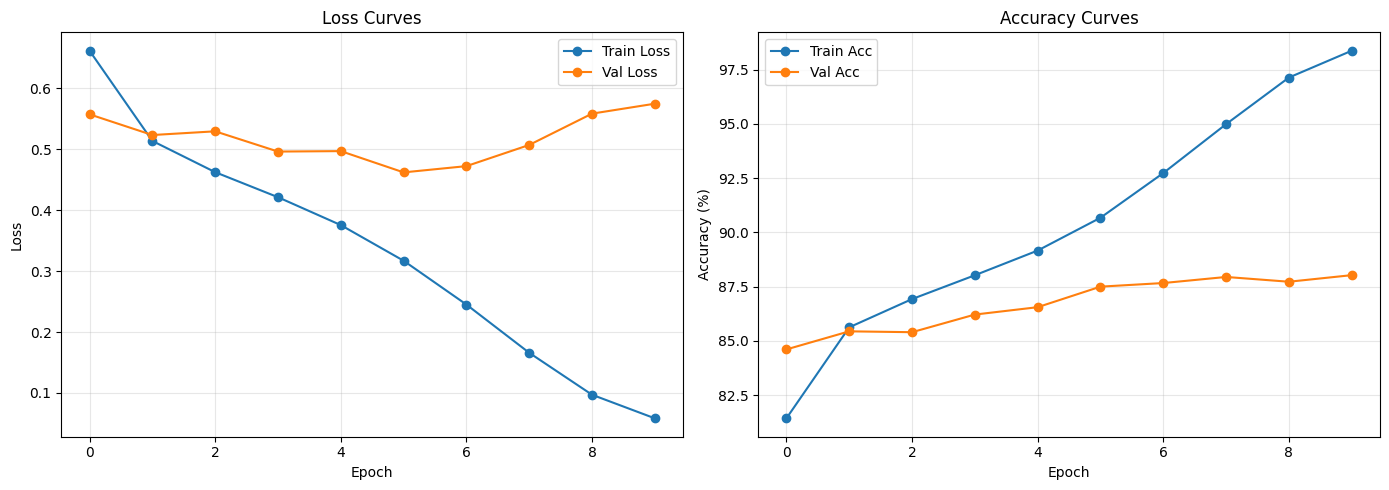

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
categories = []
for idx, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    categories.append(class_name)

models = ['best_model6', 'best_model7', 'best_model8', 'best_model10']
for model_name in models:
    checkpoint = torch.load(f'{model_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded {model_name} from epoch {checkpoint['epoch']+1} (Val Acc: {checkpoint['val_acc']:.2f}%)")

    test_loss, test_acc, test_preds, test_labels = validate_one_epoch(
        model, test_loader, criterion, device
    )

    print(f"Test Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=categories, digits=4))
    print("="*40)

Loaded best_model6 from epoch 6 (Val Acc: 87.50%)


Validating: 100%|██████████| 938/938 [00:12<00:00, 74.01it/s] 


Test Results:
Test Loss: 0.4547
Test Accuracy: 87.70%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.5831    0.6700    0.6235      1000
        airplane     0.8483    0.8950    0.8710      1000
     alarm_clock     0.9140    0.8820    0.8977      1000
       ambulance     0.9461    0.9650    0.9554      1000
           angel     0.9085    0.9030    0.9057      1000
animal_migration     0.8168    0.8160    0.8164      1000
             ant     0.8894    0.9170    0.9030      1000
           anvil     0.9482    0.9150    0.9313      1000
           apple     0.9715    0.9560    0.9637      1000
             arm     0.9601    0.8420    0.8972      1000
       asparagus     0.8341    0.8950    0.8635      1000
             axe     0.9662    0.9150    0.9399      1000
        backpack     0.9125    0.8550    0.8828      1000
          banana     0.9413    0.9300    0.9356      1000
         bandage     0.8324    0.8690    0.8503     

Validating: 100%|██████████| 938/938 [00:12<00:00, 72.37it/s] 


Test Results:
Test Loss: 0.4600
Test Accuracy: 87.99%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.5772    0.6770    0.6231      1000
        airplane     0.8470    0.8910    0.8684      1000
     alarm_clock     0.9034    0.8980    0.9007      1000
       ambulance     0.9744    0.9530    0.9636      1000
           angel     0.9496    0.8660    0.9059      1000
animal_migration     0.7202    0.8650    0.7860      1000
             ant     0.9646    0.8720    0.9160      1000
           anvil     0.9054    0.9280    0.9165      1000
           apple     0.9689    0.9660    0.9675      1000
             arm     0.9221    0.9000    0.9109      1000
       asparagus     0.8808    0.8790    0.8799      1000
             axe     0.9476    0.9220    0.9346      1000
        backpack     0.8794    0.8900    0.8847      1000
          banana     0.9381    0.9390    0.9385      1000
         bandage     0.8635    0.8670    0.8653     

Validating: 100%|██████████| 938/938 [00:13<00:00, 72.01it/s] 


Test Results:
Test Loss: 0.5003
Test Accuracy: 88.03%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6674    0.6100    0.6374      1000
        airplane     0.8007    0.9200    0.8562      1000
     alarm_clock     0.9158    0.8920    0.9037      1000
       ambulance     0.9430    0.9590    0.9509      1000
           angel     0.8896    0.9190    0.9041      1000
animal_migration     0.8031    0.8200    0.8115      1000
             ant     0.9252    0.8900    0.9072      1000
           anvil     0.9004    0.9310    0.9154      1000
           apple     0.9432    0.9640    0.9535      1000
             arm     0.9031    0.8950    0.8990      1000
       asparagus     0.8940    0.8600    0.8767      1000
             axe     0.9359    0.9340    0.9349      1000
        backpack     0.8954    0.8730    0.8841      1000
          banana     0.9494    0.9380    0.9437      1000
         bandage     0.8919    0.8580    0.8746     

Validating: 100%|██████████| 938/938 [00:13<00:00, 69.65it/s]

Test Results:
Test Loss: 0.5581
Test Accuracy: 88.31%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6524    0.6420    0.6472      1000
        airplane     0.8324    0.8990    0.8644      1000
     alarm_clock     0.8973    0.9000    0.8987      1000
       ambulance     0.9626    0.9510    0.9567      1000
           angel     0.9242    0.9020    0.9130      1000
animal_migration     0.8282    0.8100    0.8190      1000
             ant     0.9178    0.9050    0.9114      1000
           anvil     0.9369    0.9210    0.9289      1000
           apple     0.9564    0.9660    0.9612      1000
             arm     0.8731    0.9150    0.8936      1000
       asparagus     0.8890    0.8650    0.8768      1000
             axe     0.9511    0.9330    0.9419      1000
        backpack     0.8980    0.8800    0.8889      1000
          banana     0.9351    0.9360    0.9355      1000
         bandage     0.8822    0.8610    0.8715     

In [ ]:
print("\n📋 Classification Report:")
print("="*70)
print(classification_report(test_labels, test_preds, target_names=classes, digits=4))